# Deep Sets experiment

In [1]:
from functools import partial

import torch

from deepsets import (
    DeepSetsClassifier,
    LearnableSetDataset,
    OrderedMLPClassifier,
    make_deepsets_classifier,
)
from evaluation import evaluate_permutation_invariance, print_permutation_audit
from meta_learning import MetaLearner
from meta_loss_functions import (
    aligned_element_separation,
    combine_regularizers,
    cross_entropy_loss,
    pairwise_class_cross_entropy,
    within_set_separation,
)
from visualization import plot_meta_history, plot_set_dataset

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Experiment 1: two classes

In [ ]:
# Dataset
SEED_2 = 42
NUM_CLASSES_2 = 2
SAMPLES_PER_CLASS_2 = 40
SET_SIZE_2 = 10
ELEMENT_DIM_2 = 2

# Learner
HIDDEN_DIM_2 = 32
EMBEDDING_DIM_2 = 32
INNER_LR_2 = 0.5
INNER_STEPS_2 = 5
LEARNERS_PER_STEP_2 = 3
TRAIN_FRACTION_2 = 0.75

# Meta-optimization
META_STEPS_2 = 1500
META_LR_2 = 3e-3
PAIRWISE_TEMPERATURE_2 = 0.2

# Regularization
WITHIN_SET_MIN_DISTANCE_2 = 0.2
WITHIN_SET_WEIGHT_2 = 100
ALIGNED_MIN_DISTANCE_2 = 0.2
ALIGNED_WEIGHT_2 = 0.1

torch.manual_seed(SEED_2)

In [19]:
generator_2 = LearnableSetDataset(
    num_classes=NUM_CLASSES_2,
    samples_per_class=SAMPLES_PER_CLASS_2,
    set_size=SET_SIZE_2,
    element_dim=ELEMENT_DIM_2,
)

deepsets_factory_2 = partial(
    make_deepsets_classifier,
    element_dim=ELEMENT_DIM_2,
    hidden_dim=HIDDEN_DIM_2,
    embedding_dim=EMBEDDING_DIM_2,
)

regularizer_2 = combine_regularizers(
    partial(
        within_set_separation,
        minimum_distance=WITHIN_SET_MIN_DISTANCE_2,
        weight=WITHIN_SET_WEIGHT_2,
    ),
    partial(
        aligned_element_separation,
        minimum_distance=ALIGNED_MIN_DISTANCE_2,
        weight=ALIGNED_WEIGHT_2,
    ),
)

meta_learner_2 = MetaLearner(
    generator=generator_2,
    learner_factory=deepsets_factory_2,
    inner_loss_fn=cross_entropy_loss,
    meta_loss_fn=partial(
        pairwise_class_cross_entropy,
        temperature=PAIRWISE_TEMPERATURE_2,
    ),
    regularization_fn=regularizer_2,
    num_classes=NUM_CLASSES_2,
    meta_lr=META_LR_2,
    inner_lr=INNER_LR_2,
    inner_steps=INNER_STEPS_2,
    learners_per_step=LEARNERS_PER_STEP_2,
    train_fraction=TRAIN_FRACTION_2,
    first_order=False,
    seed=SEED_2,
)

step=0001 loss=0.7367 accuracy=0.583
step=0100 loss=0.6983 accuracy=0.517
step=0200 loss=0.6946 accuracy=0.600
step=0300 loss=0.6920 accuracy=0.767
step=0400 loss=0.6322 accuracy=1.000
step=0500 loss=0.5574 accuracy=1.000
step=0600 loss=0.5285 accuracy=1.000
step=0700 loss=0.4186 accuracy=1.000
step=0800 loss=0.4070 accuracy=1.000
step=0900 loss=0.3857 accuracy=1.000
step=1000 loss=0.5032 accuracy=1.000
step=1100 loss=0.3886 accuracy=1.000
step=1200 loss=0.4669 accuracy=1.000
step=1300 loss=0.2950 accuracy=1.000
step=1400 loss=0.3980 accuracy=1.000
step=1500 loss=0.3264 accuracy=1.000


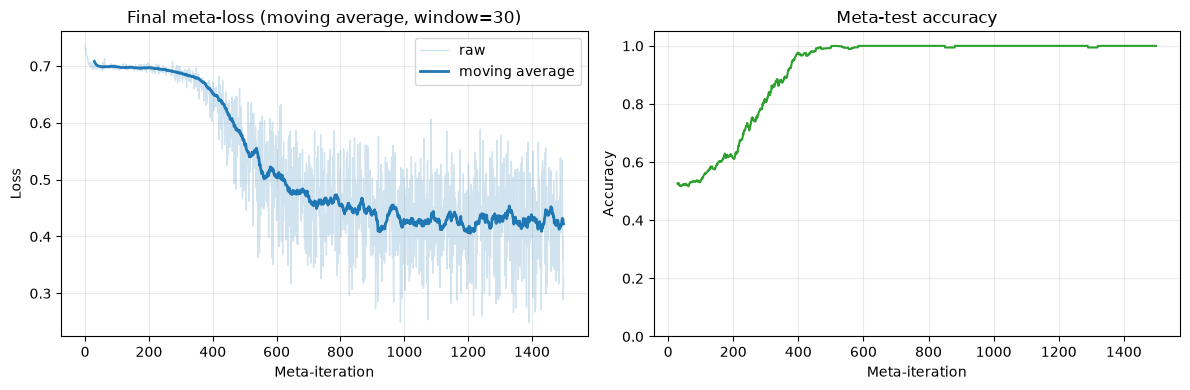

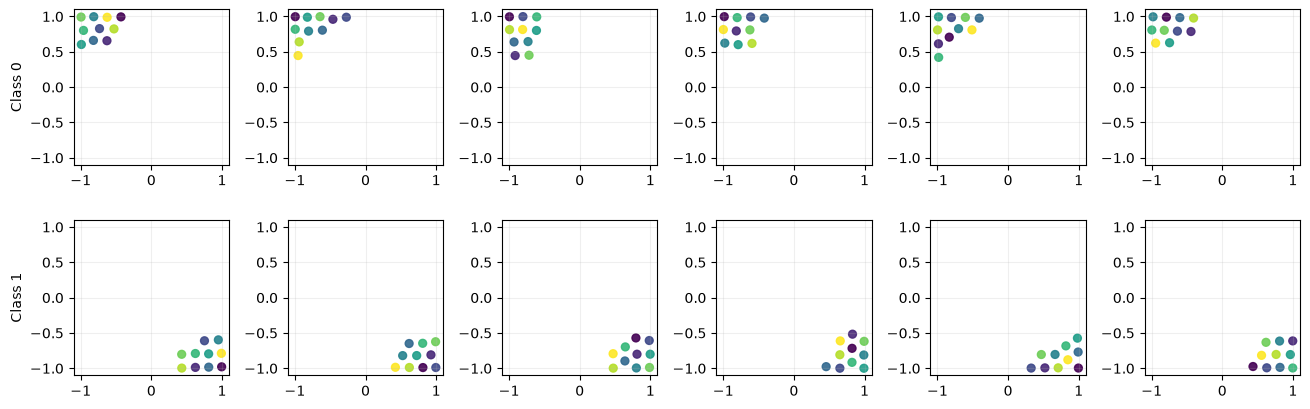

In [20]:
history_2 = meta_learner_2.train(steps=META_STEPS_2, log_every=100)
x_2, y_2 = meta_learner_2.frozen_dataset()

plot_meta_history(history_2, smoothing_window=30);
plot_set_dataset(x_2, y_2, samples_per_class=6);

In [21]:
deepsets_audit_2 = evaluate_permutation_invariance(
    DeepSetsClassifier,
    {
        "element_dim": ELEMENT_DIM_2,
        "hidden_dim": HIDDEN_DIM_2,
        "embedding_dim": EMBEDDING_DIM_2,
    },
    x_2,
    y_2,
    num_classes=NUM_CLASSES_2,
    trials=30,
    permutations_per_trial=50,
    train_fraction=TRAIN_FRACTION_2,
    training_steps=INNER_STEPS_2,
    learning_rate=INNER_LR_2,
    seed=10_000,
)
print_permutation_audit("Deep Sets", deepsets_audit_2)

Deep Sets
  original train -> original test: 1.0000 +- 0.0000
  original train -> permuted test: 1.0000 +- 0.0000
  permuted train -> original test: 1.0000 +- 0.0000
  permuted train -> permuted test: 1.0000 +- 0.0000


## Experiment 2: four classes

In [48]:
# Dataset
SEED_4 = 43
NUM_CLASSES_4 = 4
SAMPLES_PER_CLASS_4 = 20
SET_SIZE_4 = 10
ELEMENT_DIM_4 = 2

# Learner
HIDDEN_DIM_4 = 128
EMBEDDING_DIM_4 = 128
INNER_LR_4 = 0.5
INNER_STEPS_4 = 7
LEARNERS_PER_STEP_4 = 3
TRAIN_FRACTION_4 = 0.75

# Meta-optimization
META_STEPS_4 = 2000
META_LR_4 = 3e-3
PAIRWISE_TEMPERATURE_4 = 0.5

# Regularization
WITHIN_SET_MIN_DISTANCE_4 = 0.2
WITHIN_SET_WEIGHT_4 = 100
ALIGNED_MIN_DISTANCE_4 = 0.2
ALIGNED_WEIGHT_4 = 0.1

torch.manual_seed(SEED_4)

In [49]:
generator_4 = LearnableSetDataset(
    num_classes=NUM_CLASSES_4,
    samples_per_class=SAMPLES_PER_CLASS_4,
    set_size=SET_SIZE_4,
    element_dim=ELEMENT_DIM_4,
)

deepsets_factory_4 = partial(
    make_deepsets_classifier,
    element_dim=ELEMENT_DIM_4,
    hidden_dim=HIDDEN_DIM_4,
    embedding_dim=EMBEDDING_DIM_4,
)

regularizer_4 = combine_regularizers(
    partial(
        within_set_separation,
        minimum_distance=WITHIN_SET_MIN_DISTANCE_4,
        weight=WITHIN_SET_WEIGHT_4,
    ),
    partial(
        aligned_element_separation,
        minimum_distance=ALIGNED_MIN_DISTANCE_4,
        weight=ALIGNED_WEIGHT_4,
    ),
)

meta_learner_4 = MetaLearner(
    generator=generator_4,
    learner_factory=deepsets_factory_4,
    inner_loss_fn=cross_entropy_loss,
    meta_loss_fn=partial(
        pairwise_class_cross_entropy,
        temperature=PAIRWISE_TEMPERATURE_4,
    ),
    regularization_fn=regularizer_4,
    num_classes=NUM_CLASSES_4,
    meta_lr=META_LR_4,
    inner_lr=INNER_LR_4,
    inner_steps=INNER_STEPS_4,
    learners_per_step=LEARNERS_PER_STEP_4,
    train_fraction=TRAIN_FRACTION_4,
    first_order=False,
    seed=SEED_4,
)

step=0001 loss=0.7305 accuracy=0.167
step=0100 loss=0.6766 accuracy=0.467
step=0200 loss=0.4271 accuracy=0.500
step=0300 loss=0.4020 accuracy=0.500
step=0400 loss=0.3799 accuracy=0.667
step=0500 loss=0.3786 accuracy=0.583
step=0600 loss=0.3723 accuracy=0.583
step=0700 loss=0.3493 accuracy=0.700
step=0800 loss=0.2990 accuracy=0.733
step=0900 loss=0.2663 accuracy=0.750
step=1000 loss=0.2768 accuracy=0.750
step=1100 loss=0.2470 accuracy=0.850
step=1200 loss=0.1885 accuracy=1.000
step=1300 loss=0.1475 accuracy=1.000
step=1400 loss=0.1273 accuracy=1.000
step=1500 loss=0.1242 accuracy=1.000
step=1600 loss=0.1021 accuracy=1.000
step=1700 loss=0.0816 accuracy=1.000
step=1800 loss=0.0922 accuracy=1.000
step=1900 loss=0.0566 accuracy=1.000
step=2000 loss=0.0675 accuracy=1.000


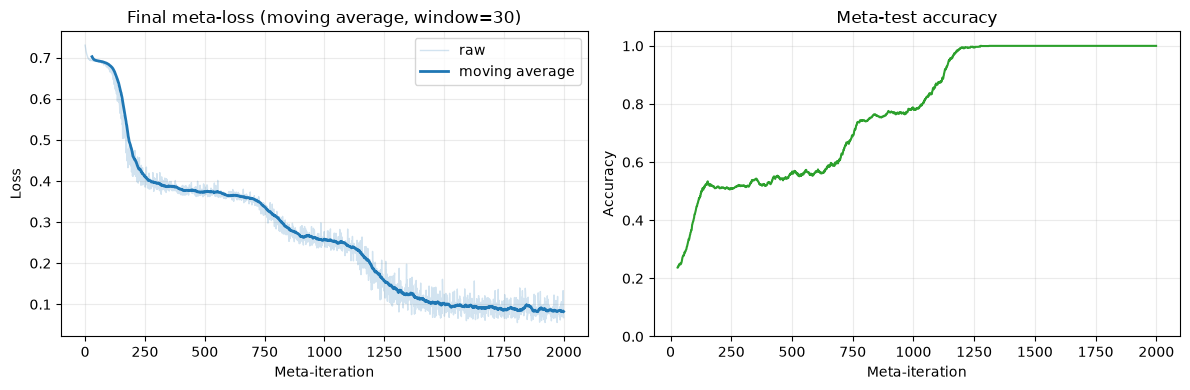

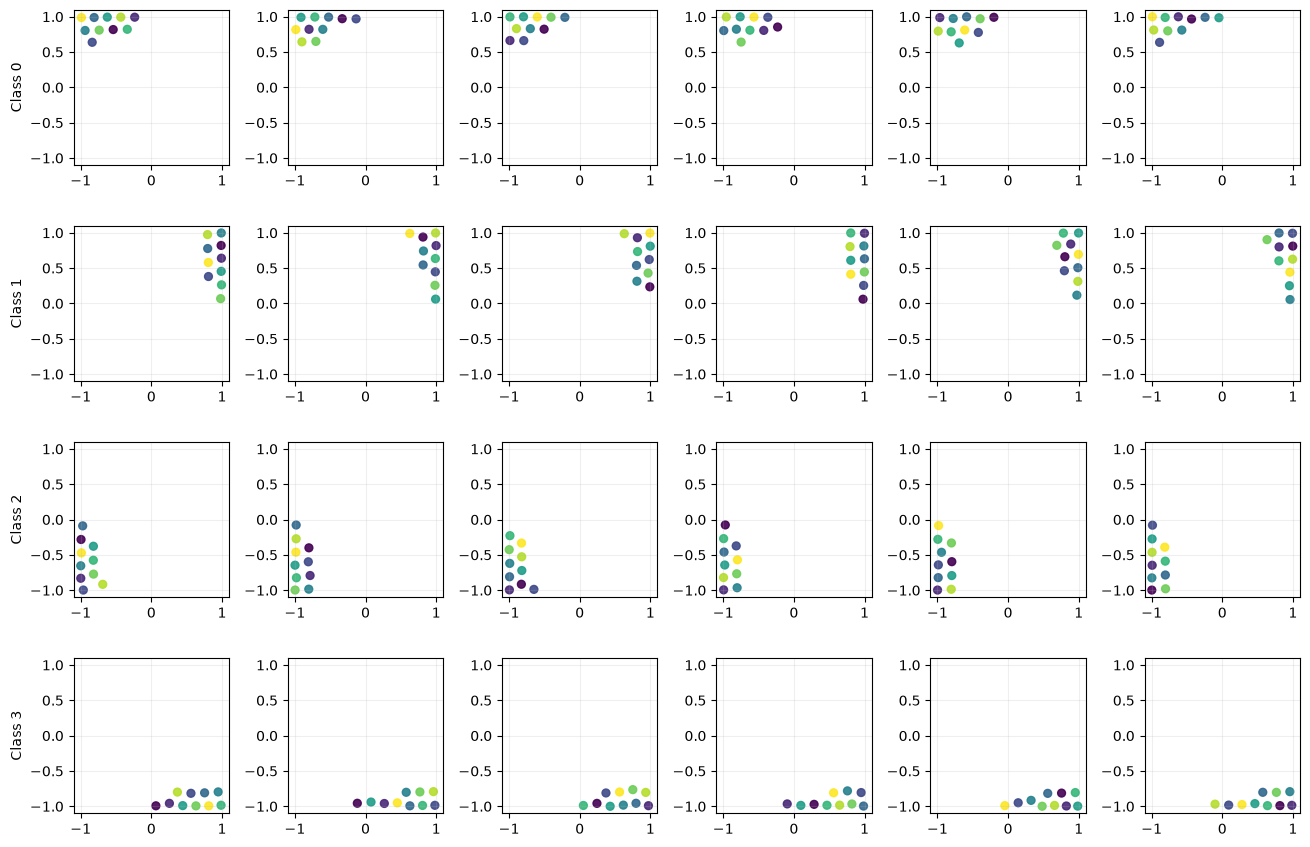

In [50]:
history_4 = meta_learner_4.train(steps=META_STEPS_4, log_every=100)
x_4, y_4 = meta_learner_4.frozen_dataset()

plot_meta_history(history_4, smoothing_window=30);
plot_set_dataset(x_4, y_4, samples_per_class=6);

In [51]:
deepsets_audit_4 = evaluate_permutation_invariance(
    DeepSetsClassifier,
    {
        "element_dim": ELEMENT_DIM_4,
        "hidden_dim": HIDDEN_DIM_4,
        "embedding_dim": EMBEDDING_DIM_4,
    },
    x_4,
    y_4,
    num_classes=NUM_CLASSES_4,
    trials=30,
    permutations_per_trial=50,
    train_fraction=TRAIN_FRACTION_4,
    training_steps=INNER_STEPS_4,
    learning_rate=INNER_LR_4,
    seed=20_000,
)
print_permutation_audit("Deep Sets", deepsets_audit_4)

Deep Sets
  original train -> original test: 1.0000 +- 0.0000
  original train -> permuted test: 1.0000 +- 0.0000
  permuted train -> original test: 1.0000 +- 0.0000
  permuted train -> permuted test: 1.0000 +- 0.0000
